<a href="https://colab.research.google.com/github/shaipshiverya/Data_Analysis_python_projects/blob/main/project_7_football_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Project Introduction: FIFA World Cup Historical Analysis
This project explores the rich history of the FIFA World Cup through structured data analysis, uncovering trends in performance, scoring, national dominance, and tournament evolution. Using datasets spanning from 1930 to the present, we calculate key performance indicators (KPIs) to measure team efficiency, goal-scoring patterns, and competitive balance across eras. The goal is to transform raw match and ranking data into actionable insights — revealing which nations have dominated, how the game has evolved, and what metrics define success on football’s biggest stage.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# 🗂️ Step 1: Data Collection & Understanding
Load datasets. (matches, rankings, players, tournaments)

Understand the structure of each dataset.

Identify relationships between datasets.


In [ ]:
# Load datasets (matches, rankings, players, tournaments)

df_history= pd.read_csv('/content/fifa_world_cup_history.csv')
df_top_scorer= pd.read_csv('/content/fifa_world_cup_top_scorers.csv')
df_rank= pd.read_csv('/content/fifa_world_rankings_jan_2026.csv')
df_comp= pd.read_csv('/content/football_major_competitions.csv')

### Understand the structure of each dataset.

In [ ]:
print('FIFA_WORLD_CUP_HISTORY',df_history.head())



FIFA_WORLD_CUP_HISTORY    Year Host_Country        Winner       Runner_Up Third_Place Fourth_Place  \
0  1930      Uruguay       Uruguay       Argentina         USA   Yugoslavia   
1  1934        Italy         Italy  Czechoslovakia     Germany      Austria   
2  1938       France         Italy         Hungary      Brazil       Sweden   
3  1950       Brazil       Uruguay          Brazil      Sweden        Spain   
4  1954  Switzerland  West Germany         Hungary     Austria      Uruguay   

   Total_Goals  Matches_Played  Teams  Goals_Per_Match  
0           70              18     13             3.89  
1           70              17     16             4.12  
2           84              18     15             4.67  
3           88              22     13             4.00  
4          140              26     16             5.38  


In [ ]:
print('FIFA_WORLD_CUP_TOP_SCORER',df_top_scorer.head())

FIFA_WORLD_CUP_TOP_SCORER    Year         Host             Player         Country  Goals
0  1930      Uruguay  Guillermo Stábile       Argentina      8
1  1934        Italy    Oldřich Nejedlý  Czechoslovakia      5
2  1938       France           Leônidas          Brazil      7
3  1950       Brazil             Ademir          Brazil      8
4  1954  Switzerland      Sándor Kocsis         Hungary     11


In [ ]:
print('FIFA_WORLD_RANKING',df_rank.head())

FIFA_WORLD_RANKING    Rank    Country   Points Confederation  World_Cup_Titles    Best_WC_Finish  \
0     1      Spain  1877.18          UEFA                 1  Champions (2010)   
1     2  Argentina  1873.33      CONMEBOL                 3  Champions (2022)   
2     3     France  1870.00          UEFA                 2  Champions (2018)   
3     4    England  1834.12          UEFA                 1  Champions (1966)   
4     5     Brazil  1760.46      CONMEBOL                 5  Champions (2002)   

   Continental_Titles  
0                  12  
1                  15  
2                   3  
3                   0  
4                   9  


In [ ]:
print('FOOTBALL_MAJOR_COMPETITION',df_comp.head())



FOOTBALL_MAJOR_COMPETITION                   Competition  Founded Organizer        Frequency  \
0              FIFA World Cup     1930      FIFA    Every 4 years   
1       UEFA Champions League     1955      UEFA           Annual   
2  UEFA European Championship     1960      UEFA    Every 4 years   
3                Copa América     1916  CONMEBOL  Every 2–4 years   
4       Africa Cup of Nations     1957       CAF    Every 2 years   

            Type         Region    Current_Champion Most_Successful_Team  \
0  International         Global    Argentina (2022)               Brazil   
1           Club         Europe  Real Madrid (2024)          Real Madrid   
2  International         Europe        Spain (2024)      Germany / Spain   
3  International  South America    Argentina (2024)  Argentina / Uruguay   
4  International         Africa  Ivory Coast (2024)                Egypt   

   Most_Titles  
0            5  
1           15  
2            3  
3           15  
4            7  

# 🧹 Step 2: Data Cleaning & Preprocessing

Handle missing values

Check and remove duplicates

Standardize column names and formats

Convert data types (e.g., dates, integers)



In [ ]:
# Handle missing values

print('FIFA_WORLD_CUP_HISTORY',df_history.isna().sum())

print('FIFA_WORLD_CUP_TOP_SCORER',df_top_scorer.isna().sum())

print('FIFA_WORLD_RANKING',df_rank.isna().sum())

print('FOOTBALL_MAJOR_COMPETITION',df_comp.isna().sum())

FIFA_WORLD_CUP_HISTORY Year               0
Host_Country       0
Winner             0
Runner_Up          0
Third_Place        0
Fourth_Place       0
Total_Goals        0
Matches_Played     0
Teams              0
Goals_Per_Match    0
dtype: int64
FIFA_WORLD_CUP_TOP_SCORER Year       0
Host       0
Player     0
Country    0
Goals      0
dtype: int64
FIFA_WORLD_RANKING Rank                  0
Country               0
Points                0
Confederation         0
World_Cup_Titles      0
Best_WC_Finish        0
Continental_Titles    0
dtype: int64
FOOTBALL_MAJOR_COMPETITION Competition             0
Founded                 0
Organizer               0
Frequency               0
Type                    0
Region                  0
Current_Champion        0
Most_Successful_Team    0
Most_Titles             0
dtype: int64


In [ ]:
# check duplicates

print('FIFA_WORLD_CUP_HISTORY',df_history.duplicated().sum())

print('FIFA_WORLD_CUP_TOP_SCORER',df_top_scorer.duplicated().sum())

print('FIFA_WORLD_RANKING', df_rank.duplicated().sum())

print('FOOTBALL_MAJOR_COMPETITION',df_comp.duplicated().sum())

FIFA_WORLD_CUP_HISTORY 0
FIFA_WORLD_CUP_TOP_SCORER 0
FIFA_WORLD_RANKING 0
FOOTBALL_MAJOR_COMPETITION 0


### Standardize column names and formats

In [ ]:
# Standardize column names and formats

print('FIFA_WORLD_CUP_HISTORY',df_history.info())
print('FIFA_WORLD_CUP_HISTORY',df_history.head())

print('FIFA_WORLD_CUP_TOP_SCORER',df_top_scorer.info())
print('FIFA_WORLD_CUP_TOP_SCORER',df_top_scorer.head())

print('FIFA_WORLD_RANKING',df_rank.info())
print('FIFA_WORLD_RANKING',df_rank.head())

print('FOOTBALL_MAJOR_COMPETITION',df_comp.info())
print('FOOTBALL_MAJOR_COMPETITION',df_comp.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             22 non-null     int64  
 1   Host_Country     22 non-null     object 
 2   Winner           22 non-null     object 
 3   Runner_Up        22 non-null     object 
 4   Third_Place      22 non-null     object 
 5   Fourth_Place     22 non-null     object 
 6   Total_Goals      22 non-null     int64  
 7   Matches_Played   22 non-null     int64  
 8   Teams            22 non-null     int64  
 9   Goals_Per_Match  22 non-null     float64
dtypes: float64(1), int64(4), object(5)
memory usage: 1.8+ KB
FIFA_WORLD_CUP_HISTORY None
FIFA_WORLD_CUP_HISTORY    Year Host_Country        Winner       Runner_Up Third_Place Fourth_Place  \
0  1930      Uruguay       Uruguay       Argentina         USA   Yugoslavia   
1  1934        Italy         Italy  Czechoslovakia     Germany      Austri

In [ ]:
print("World Cup Data:", df_history.shape)
print("Top Scorers Data:", df_top_scorer.shape)
print("Rankings Data:", df_rank.shape)
print("Competitions Data:", df_comp.shape)

World Cup Data: (22, 10)
Top Scorers Data: (22, 5)
Rankings Data: (30, 7)
Competitions Data: (15, 9)


# 🔍 Step 3: Exploratory Data Analysis (EDA)


# DATA ANALYSIS REGARDING " *WORLD CUP HISTORY ⚽*"

In [ ]:
df_history.head(22)

,Year,Host_Country,Winner,Runner_Up,Third_Place,Fourth_Place,Total_Goals,Matches_Played,Teams,Goals_Per_Match
0,1930,Uruguay,Uruguay,Argentina,USA,Yugoslavia,70,18,13,3.89
1,1934,Italy,Italy,Czechoslovakia,Germany,Austria,70,17,16,4.12
2,1938,France,Italy,Hungary,Brazil,Sweden,84,18,15,4.67
3,1950,Brazil,Uruguay,Brazil,Sweden,Spain,88,22,13,4.00
4,1954,Switzerland,West Germany,Hungary,Austria,Uruguay,140,26,16,5.38
5,1958,Sweden,Brazil,Sweden,France,West Germany,126,35,16,3.60
6,1962,Chile,Brazil,Czechoslovakia,Chile,Yugoslavia,89,32,16,2.78
7,1966,England,England,West Germany,Portugal,Soviet Union,89,32,16,2.78
8,1970,Mexico,Brazil,Italy,West Germany,Uruguay,95,32,16,2.97
9,1974,West Germany,West Germany,Netherlands,Poland,Brazil,97,38,16,2.55


In [ ]:
# Total Goals
df_history['Total_Goals'].sum()

np.int64(2720)

total number of goals scoreed till now are 2720

In [ ]:
# Most World Cup Winners¶
winner_counts  = df_history['Winner'].value_counts().reset_index()

fig = px.bar(winner_counts , x = 'Winner', y = 'count',title ='MOST FIFA world cup winner',
                            text_auto= True, color = 'count', color_continuous_scale='viridis',
                            template = 'presentation')
fig.show()

In [ ]:
# Country With Most Runner-Up¶
most_runner = df_history['Runner_Up'].value_counts().reset_index()

fig = px.bar(most_runner , x = 'Runner_Up', y = 'count' , title = 'Country With Most Runner-Up',
                            text_auto= True ,color = 'count', color_continuous_scale='jet',
                            template = 'presentation'
)


fig.show()

In [ ]:
# Country With Most Third Places

third_runner = df_history['Third_Place'].value_counts().reset_index()
fig = px.bar(third_runner , x = 'Third_Place', y = 'count', title = 'Country With Most Third Places',
                           color = 'count',color_continuous_scale = 'turbo',
                          template = 'presentation'
                          )
fig.show()

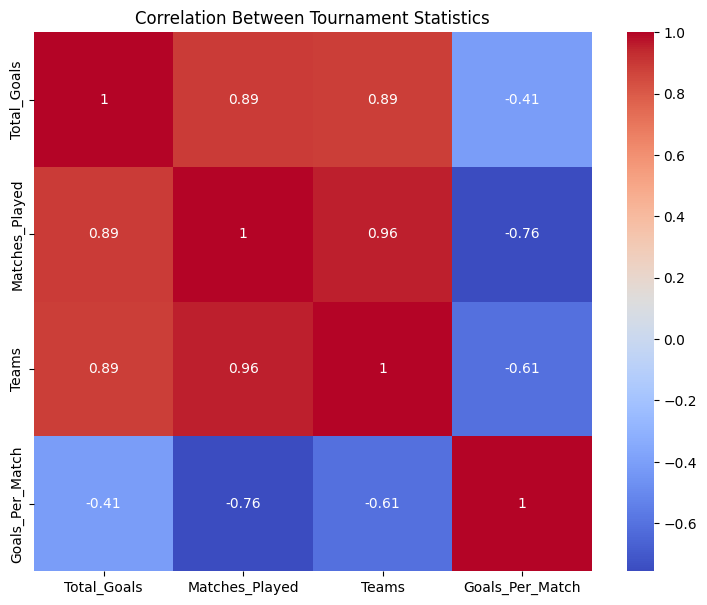

In [ ]:
# Correlation Between Tournament Statistics
corr = df_history[['Total_Goals','Matches_Played','Teams','Goals_Per_Match']].corr()

plt.figure(figsize=(9,7))
sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Between Tournament Statistics")
plt.show()

In [ ]:
# Year With Maximum Goals Per Match
q =df_history[['Year','Winner','Total_Goals',	'Matches_Played','Teams','Goals_Per_Match']].sort_values(by = 'Goals_Per_Match',ascending = False).head()
q


,Year,Winner,Total_Goals,Matches_Played,Teams,Goals_Per_Match
4,1954,West Germany,140,26,16,5.38
2,1938,Italy,84,18,15,4.67
1,1934,Italy,70,17,16,4.12
3,1950,Uruguay,88,22,13,4.00
0,1930,Uruguay,70,18,13,3.89


In [ ]:
fig = px.bar(q, x = 'Year',y= 'Goals_Per_Match',title = ' Year With Maximum Goals Per Match',
            text_auto = True , color ='Year',color_continuous_scale= 'rainbow',
             template = 'presentation')
fig.show()

In [ ]:
# Year With Maximum Goals
df_history[['Year','Winner','Total_Goals']].sort_values(by = 'Total_Goals',ascending = False).head()



,Year,Winner,Total_Goals
21,2022,Argentina,172
15,1998,France,171
19,2014,Germany,171
20,2018,France,169
16,2002,Brazil,161


In [ ]:
# Host Country Performance¶

host_wins = df_history[df_history['Host_Country'] == df_history['Winner']]

host_wins[['Year','Host_Country','Winner']]

,Year,Host_Country,Winner
0,1930,Uruguay,Uruguay
1,1934,Italy,Italy
7,1966,England,England
9,1974,West Germany,West Germany
10,1978,Argentina,Argentina
15,1998,France,France


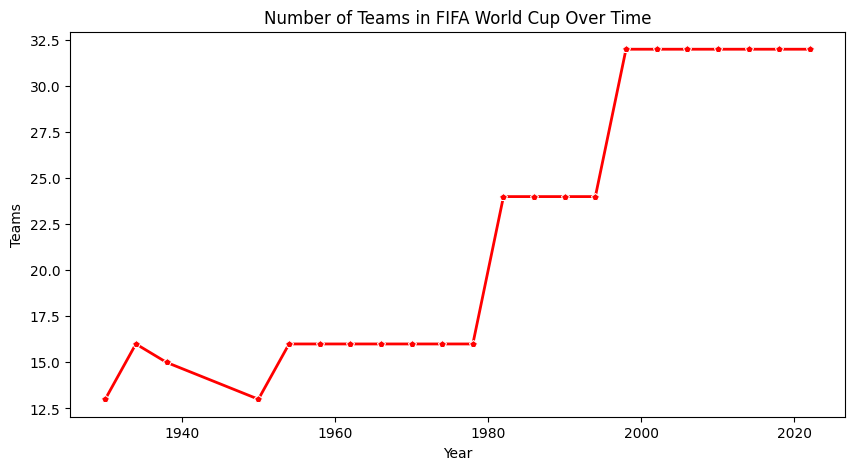

In [ ]:
# Tournament Growth Over Time

plt.figure(figsize=(10,5))

sns.lineplot(data = df_history , x='Year', y='Teams',  marker='p',color ='r',linewidth = 2)

plt.title("Number of Teams in FIFA World Cup Over Time")
plt.xlabel('Year')
plt.ylabel('Teams')
plt.show()

# DATA ANALYSIS REGARDING " *TOP SCORER IN THE WORLD CUP ⚽*"

In [ ]:
df_top_scorer.head(4)

,Year,Host,Player,Country,Goals
0,1930,Uruguay,Guillermo Stábile,Argentina,8
1,1934,Italy,Oldřich Nejedlý,Czechoslovakia,5
2,1938,France,Leônidas,Brazil,7
3,1950,Brazil,Ademir,Brazil,8


In [ ]:
# Top_scorer_in_the_world_cup

a = df_top_scorer[['Player','Goals']].sort_values(by = 'Goals',ascending = False).head(10).reset_index()
a

,index,Player,Goals
0,5,Just Fontaine,13
1,4,Sándor Kocsis,11
2,8,Gerd Müller,10
3,7,Eusébio,9
4,3,Ademir,8
5,0,Guillermo Stábile,8
6,21,Kylian Mbappé,8
7,16,Ronaldo,8
8,9,Grzegorz Lato,7
9,2,Leônidas,7


In [ ]:
fig = px.bar(a , x = 'Player' , y = 'Goals' , title = ' Top_scorer_in_the_world_cup',
            text_auto = True , color ='Player' , color_continuous_scale= 'rainbow',
            template = 'presentation')
fig.show()

In [ ]:
df_top_scorer.head()

,Year,Host,Player,Country,Goals
0,1930,Uruguay,Guillermo Stábile,Argentina,8
1,1934,Italy,Oldřich Nejedlý,Czechoslovakia,5
2,1938,France,Leônidas,Brazil,7
3,1950,Brazil,Ademir,Brazil,8
4,1954,Switzerland,Sándor Kocsis,Hungary,11


In [ ]:
# Country and Player with most goals

top_combos = df_top_scorer.sort_values(by = 'Goals', ascending=False)[['Year', 'Player', 'Country', 'Goals', 'Host']].head(10)

print("Top 10 country + player combinations with most goals in a single World Cup:")
print(top_combos.to_string(index=False))



Top 10 country + player combinations with most goals in a single World Cup:
 Year            Player      Country  Goals                Host
 1958     Just Fontaine       France     13              Sweden
 1954     Sándor Kocsis      Hungary     11         Switzerland
 1970       Gerd Müller West Germany     10              Mexico
 1966           Eusébio     Portugal      9             England
 1950            Ademir       Brazil      8              Brazil
 1930 Guillermo Stábile    Argentina      8             Uruguay
 2022     Kylian Mbappé       France      8               Qatar
 2002           Ronaldo       Brazil      8 South Korea / Japan
 1974     Grzegorz Lato       Poland      7        West Germany
 1938          Leônidas       Brazil      7              France


In [ ]:
# Top Scorers by Country

fig = px.bar( top_combos , x ='Country', y ='Goals', title = 'Top Scorers by Country', color = 'Player',
             hover_data = ['Year', 'Player', 'Host'],
            barmode = 'group', template = 'presentation'
)

fig.update_layout(height=550, title_x=0.5)
fig.show()

In [ ]:
# Country With Most Hosting Record

df_top_scorer['Country'].value_counts().head(7)

,count
Country,
Brazil,3
Argentina,2
France,2
Italy,2
Germany,2
England,2
Czechoslovakia,1


# DATA ANALYSIS REGARDING " *TOP RANKERS IN THE WORLD CUP ⚽*"

In [ ]:
df_rank.head(30)

,Rank,Country,Points,Confederation,World_Cup_Titles,Best_WC_Finish,Continental_Titles
0,1,Spain,1877.18,UEFA,1,Champions (2010),12
1,2,Argentina,1873.33,CONMEBOL,3,Champions (2022),15
2,3,France,1870.00,UEFA,2,Champions (2018),3
3,4,England,1834.12,UEFA,1,Champions (1966),0
4,5,Brazil,1760.46,CONMEBOL,5,Champions (2002),9
5,6,Portugal,1760.38,UEFA,0,3rd Place (1966),2
6,7,Netherlands,1756.27,UEFA,0,Runner-Up (2010),0
7,8,Morocco,1736.57,CAF,0,4th Place (2022),1
8,9,Belgium,1730.71,UEFA,0,3rd Place (2018),0
9,10,Germany,1724.15,UEFA,4,Champions (2014),3


In [ ]:
df_rank.nunique()

,0
Rank,30
Country,30
Points,30
Confederation,5
World_Cup_Titles,6
Best_WC_Finish,30
Continental_Titles,11


In [ ]:
# Countries with most world cup title

df_rank[['Country','World_Cup_Titles']].sort_values(by = 'World_Cup_Titles',ascending = False).head(7).reset_index()

,index,Country,World_Cup_Titles
0,4,Brazil,5
1,9,Germany,4
2,12,Italy,4
3,1,Argentina,3
4,2,France,2
5,16,Uruguay,2
6,3,England,1


In [ ]:
# Countries with most contitental title

df_rank[['Country','Continental_Titles']].sort_values(by = 'Continental_Titles',ascending = False).head(7).reset_index()

,index,Country,Continental_Titles
0,1,Argentina,15
1,16,Uruguay,15
2,0,Spain,12
3,15,Mexico,11
4,4,Brazil,9
5,28,Canada,8
6,14,United States,7


In [ ]:
q = df_rank.groupby('Confederation')['Country'].count().head()

q


,Country
Confederation,
AFC,4
CAF,4
CONCACAF,3
CONMEBOL,5
UEFA,14


# DATA ANALYSIS REGARDING " *Football_Major_Competitions⚽*"

In [ ]:
df_comp.head(15)

,Competition,Founded,Organizer,Frequency,Type,Region,Current_Champion,Most_Successful_Team,Most_Titles
0,FIFA World Cup,1930,FIFA,Every 4 years,International,Global,Argentina (2022),Brazil,5
1,UEFA Champions League,1955,UEFA,Annual,Club,Europe,Real Madrid (2024),Real Madrid,15
2,UEFA European Championship,1960,UEFA,Every 4 years,International,Europe,Spain (2024),Germany / Spain,3
3,Copa América,1916,CONMEBOL,Every 2–4 years,International,South America,Argentina (2024),Argentina / Uruguay,15
4,Africa Cup of Nations,1957,CAF,Every 2 years,International,Africa,Ivory Coast (2024),Egypt,7
5,AFC Asian Cup,1956,AFC,Every 4 years,International,Asia,Qatar (2024),Japan,4
6,Copa Libertadores,1960,CONMEBOL,Annual,Club,South America,Botafogo (2024),Independiente,7
7,UEFA Europa League,1971,UEFA,Annual,Club,Europe,Atalanta (2024),Sevilla,7
8,CONCACAF Gold Cup,1991,CONCACAF,Every 2 years,International,North America,Mexico (2023),Mexico,9
9,FIFA Women's World Cup,1991,FIFA,Every 4 years,International (Women),Global,Spain (2023),United States,4


# REMOVE year from the Current_Champion column

In [ ]:
# Split at '(' and take the text before it, then remove any extra spaces
df_comp['Current_Champion'] = df_comp['Current_Champion'].str.split('(').str[0].str.strip()

In [ ]:
df_comp.head()

,Competition,Founded,Organizer,Frequency,Type,Region,Current_Champion,Most_Successful_Team,Most_Titles
0,FIFA World Cup,1930,FIFA,Every 4 years,International,Global,Argentina,Brazil,5
1,UEFA Champions League,1955,UEFA,Annual,Club,Europe,Real Madrid,Real Madrid,15
2,UEFA European Championship,1960,UEFA,Every 4 years,International,Europe,Spain,Germany / Spain,3
3,Copa América,1916,CONMEBOL,Every 2–4 years,International,South America,Argentina,Argentina / Uruguay,15
4,Africa Cup of Nations,1957,CAF,Every 2 years,International,Africa,Ivory Coast,Egypt,7


In [ ]:
df_comp.nunique()

,0
Competition,15
Founded,13
Organizer,10
Frequency,4
Type,3
Region,9
Current_Champion,14
Most_Successful_Team,13
Most_Titles,10


In [ ]:
# Country who wins most competition

df_comp.groupby('Current_Champion')['Competition'].agg(['count', '||| '.join]).sort_values(by = 'count',ascending= False)

,count,join
Current_Champion,,
Real Madrid,3,UEFA Champions League||| FIFA Club World Cup||...
Spain,2,UEFA European Championship||| FIFA Women's Wor...
Argentina,2,FIFA World Cup||| Copa América
Bayer Leverkusen,1,German Bundesliga
Atalanta,1,UEFA Europa League
Botafogo,1,Copa Libertadores
Ivory Coast,1,Africa Cup of Nations
Manchester United,1,FA Cup
Manchester City,1,English Premier League


In [ ]:
# Frequency of each Football Competition

df_comp.groupby('Frequency')['Competition'].agg(['count', '||| '.join]).sort_values(by = 'count',ascending= False)

,count,join
Frequency,,
Annual,8,UEFA Champions League||| Copa Libertadores||| ...
Every 4 years,4,FIFA World Cup||| UEFA European Championship||...
Every 2 years,2,Africa Cup of Nations||| CONCACAF Gold Cup
Every 2–4 years,1,Copa América


In [ ]:
# FIRST Football Competition in the History

df_comp[['Competition','Founded']].sort_values('Founded').reset_index()

,index,Competition,Founded
0,10,FA Cup,1871
1,3,Copa América,1916
2,13,Spanish La Liga,1929
3,0,FIFA World Cup,1930
4,1,UEFA Champions League,1955
5,5,AFC Asian Cup,1956
6,4,Africa Cup of Nations,1957
7,2,UEFA European Championship,1960
8,6,Copa Libertadores,1960
9,14,German Bundesliga,1963


In [ ]:
# Top Organiser of the Football Tournament

df_comp['Organizer'].value_counts()

,count
Organizer,
FIFA,3
UEFA,3
CONMEBOL,2
CAF,1
AFC,1
CONCACAF,1
FA,1
FA / PL,1
RFEF / LFP,1


In [ ]:
print("\nCompetitions by Region:")
print(df_comp['Region'].value_counts())

print("\nCompetitions by Frequency:")
print(df_comp['Frequency'].value_counts())

print("\nHigh Dominance (>10 titles):")
print(df_comp[df_comp['Most_Titles'] > 10][['Competition', 'Most_Successful_Team', 'Most_Titles']])


Competitions by Region:
Region
Global           3
Europe           3
South America    2
England          2
Africa           1
Asia             1
North America    1
Spain            1
Germany          1
Name: count, dtype: int64

Competitions by Frequency:
Frequency
Annual             8
Every 4 years      4
Every 2 years      2
Every 2–4 years    1
Name: count, dtype: int64

High Dominance (>10 titles):
               Competition Most_Successful_Team  Most_Titles
1    UEFA Champions League          Real Madrid           15
3             Copa América  Argentina / Uruguay           15
10                  FA Cup              Arsenal           14
12  English Premier League    Manchester United           13
13         Spanish La Liga          Real Madrid           36
14       German Bundesliga        Bayern Munich           33


In [ ]:
r = df_comp['Region'].value_counts().reset_index()

fig = px.bar(r, x='Region', y='count', title='Competition by Region', text_auto=True)
fig.update_layout(xaxis_tickangle=-45)
fig.show()

In [ ]:
t = df_comp['Frequency'].value_counts().reset_index()
fig = px.bar(t, x='Frequency', y='count', title='Competition by Frequency', text_auto=True)
fig.update_layout(xaxis_tickangle=-45)
fig.show()

In [ ]:
# Competitions with Most Titles (> 10)
s = df_comp[df_comp['Most_Titles'] > 10][['Competition', 'Most_Successful_Team', 'Most_Titles']].reset_index(drop=True)


fig = px.bar(s, x ='Most_Titles', y ='Competition', color='Most_Titles', color_continuous_scale='viridis',
             title='Competitions with Most Titles (> 10)',
             labels={
             'Most_Titles': 'Number of Titles',
             'Competition': 'Competition Name'},
              text_auto=True,
              hover_data=['Most_Successful_Team'])

fig.update_layout(
    title_x=0.5,
    template="plotly_white",
    xaxis_title="Number of Titles Won",
    yaxis_title="Competition",)
fig.show()